In [135]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.special import factorial
from scipy.interpolate import interp1d
from scipy.integrate import quad
import re

A incerteza da grandeza $f$, $\sigma_f$, que depende das variáveis $(x_1,\,\dots,\,x_n) \in \mathbb{R}$ é
$$\sigma_f^2 = \sum_{j=1}^n \partial _{x_j} f \,\sigma_{x_j}$$

Para calcular $\mu$ e $\sigma$ foram usadas as seguintes fórmulas:
No caso de ser usado um ajuste a uma função gaussiana, é feito simplesmente o ajuste e $\mu=\mu_{fit}$ e $\sigma = \sigma_{fit}/\sqrt{N_{total}}$. 
Caso contrário, 
$$\mu = \frac{1}{N_{total}}\sum_nCN$$
$$\sigma = \frac{1}{N_{total}}\sqrt{\sum_n(C-\mu)^2N}$$

In [95]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')           

def linear(x, m, b):
    return m * x + b 

# Espetro Cs-137

In [96]:
channels_bi, counts_bi = load_spectrum('BIPR3.ASC')

bi_conv_1k_min, bi_conv_1k_max = 98, 105
bi_conv_1k_roi = slice(bi_conv_1k_min, bi_conv_1k_max)
bi_conv_mu, bi_conv_sigma, bi_conv_chi2 = compute_stat(channels_bi[bi_conv_1k_roi], counts_bi[bi_conv_1k_roi], model=None)

bi_conv_1l_min, bi_conv_1l_max = 115, 123
bi_conv_1l_roi = slice(bi_conv_1l_min, bi_conv_1l_max)
bi_conv_1l_mu, bi_conv_1l_sigma, bi_conv_1l_chi2 = compute_stat(channels_bi[bi_conv_1l_roi], counts_bi[bi_conv_1l_roi], model=None)

bi_conv_2k_min, bi_conv_2k_max = 207, 213
bi_conv_2k_roi = slice(bi_conv_2k_min, bi_conv_2k_max)
bi_conv_2k_mu, bi_conv_2k_sigma, bi_conv_2k_chi2 = compute_stat(channels_bi[bi_conv_2k_roi], counts_bi[bi_conv_2k_roi], model=None)

bi_conv_2l_min, bi_conv_2l_max = 224, 232
bi_conv_2l_roi = slice(bi_conv_2l_min, bi_conv_2l_max)
bi_conv_2l_mu, bi_conv_2l_sigma, bi_conv_2l_chi2 = compute_stat(channels_bi[bi_conv_2l_roi], counts_bi[bi_conv_2l_roi], model=None)

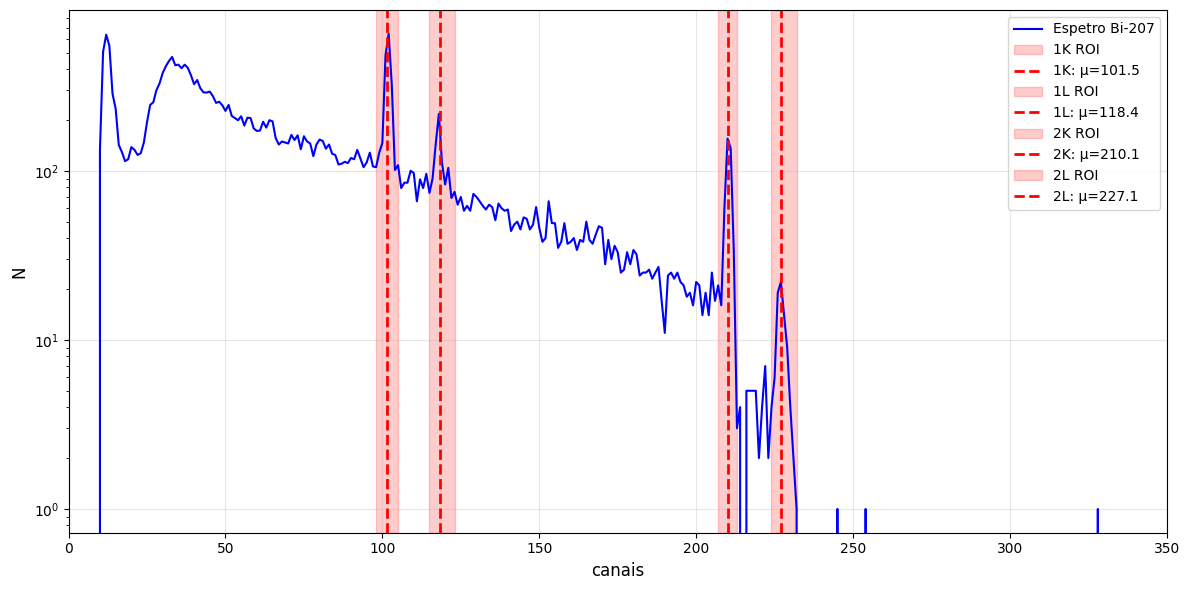

1K: 
  μ = 101.4537 ± 0.0330; χ² = nan
1L: 
  μ = 118.3576 ± 0.0667; χ² = nan
2K: 
  μ = 210.1116 ± 0.0570; χ² = nan
2L: 
  μ = 227.1125 ± 0.1750; χ² = nan


In [97]:


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_bi, counts_bi, 'b-', linewidth=1.5, label='Espetro Bi-207')

ax.axvspan(bi_conv_1k_min, bi_conv_1k_max, alpha=0.2, color='red', label='1K ROI')
ax.axvline(bi_conv_mu, color='red', linestyle='--', linewidth=2, label=f'1K: μ={bi_conv_mu:.1f}')

ax.axvspan(bi_conv_1l_min, bi_conv_1l_max, alpha=0.2, color='red', label='1L ROI')
ax.axvline(bi_conv_1l_mu, color='red', linestyle='--', linewidth=2, label=f'1L: μ={bi_conv_1l_mu:.1f}')

ax.axvspan(bi_conv_2k_min, bi_conv_2k_max, alpha=0.2, color='red', label='2K ROI')
ax.axvline(bi_conv_2k_mu, color='red', linestyle='--', linewidth=2, label=f'2K: μ={bi_conv_2k_mu:.1f}')

ax.axvspan(bi_conv_2l_min, bi_conv_2l_max, alpha=0.2, color='red', label='2L ROI')
ax.axvline(bi_conv_2l_mu, color='red', linestyle='--', linewidth=2, label=f'2L: μ={bi_conv_2l_mu:.1f}')

ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.set_xlim(0, 350)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"1K: \n  μ = {bi_conv_mu:.4f} ± {bi_conv_sigma:.4f}; χ² = {bi_conv_chi2:.4f}")
print(f"1L: \n  μ = {bi_conv_1l_mu:.4f} ± {bi_conv_1l_sigma:.4f}; χ² = {bi_conv_1l_chi2:.4f}")
print(f"2K: \n  μ = {bi_conv_2k_mu:.4f} ± {bi_conv_2k_sigma:.4f}; χ² = {bi_conv_2k_chi2:.4f}")
print(f"2L: \n  μ = {bi_conv_2l_mu:.4f} ± {bi_conv_2l_sigma:.4f}; χ² = {bi_conv_2l_chi2:.4f}")

# Pontos do Pulser

Dial 0.2

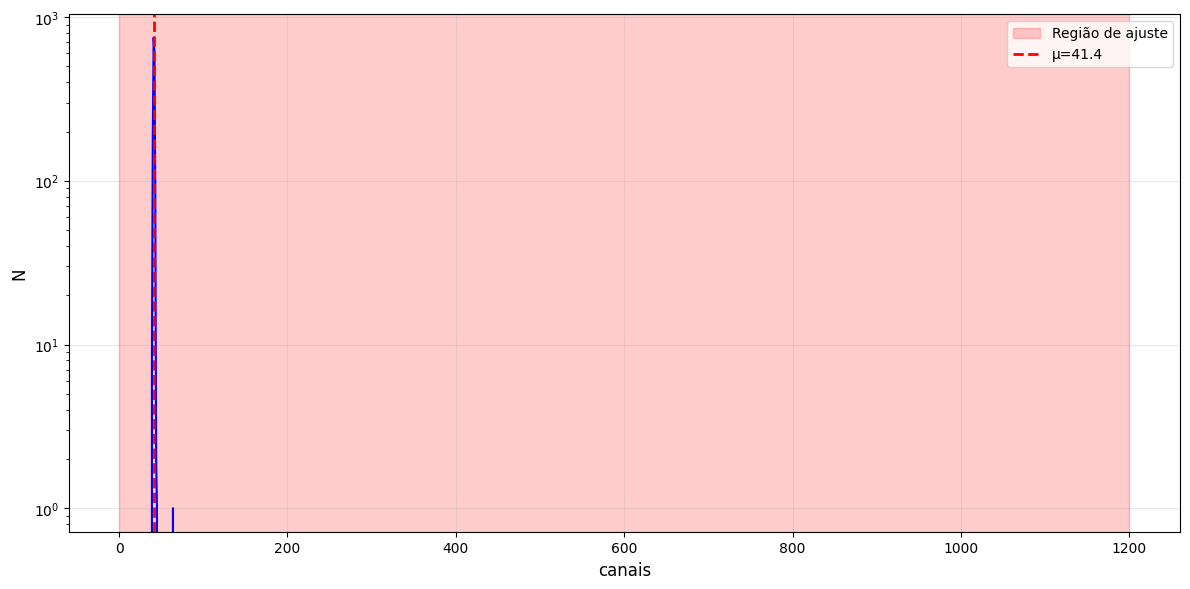

PULSER02: 
  μ = 41.3786 ± 0.0237; χ²_red = nan


In [98]:
channels_02, counts_02 = load_spectrum('PULSER02.ASC')

roi01_min, roi01_max = 0, 1200
roi01 = slice(roi01_min, roi01_max)
mu_02, sigma_02, chi2_02 = compute_stat(channels_02[roi01], counts_02[roi01], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_02, counts_02, 'b-', linewidth=1.5)
ax.axvspan(roi01_min, roi01_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_02, color='red', linestyle='--', linewidth=2, label=f'μ={mu_02:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER02: \n  μ = {mu_02:.4f} ± {sigma_02:.4f}; χ²_red = {chi2_02:.4f}")

Dial 0.4

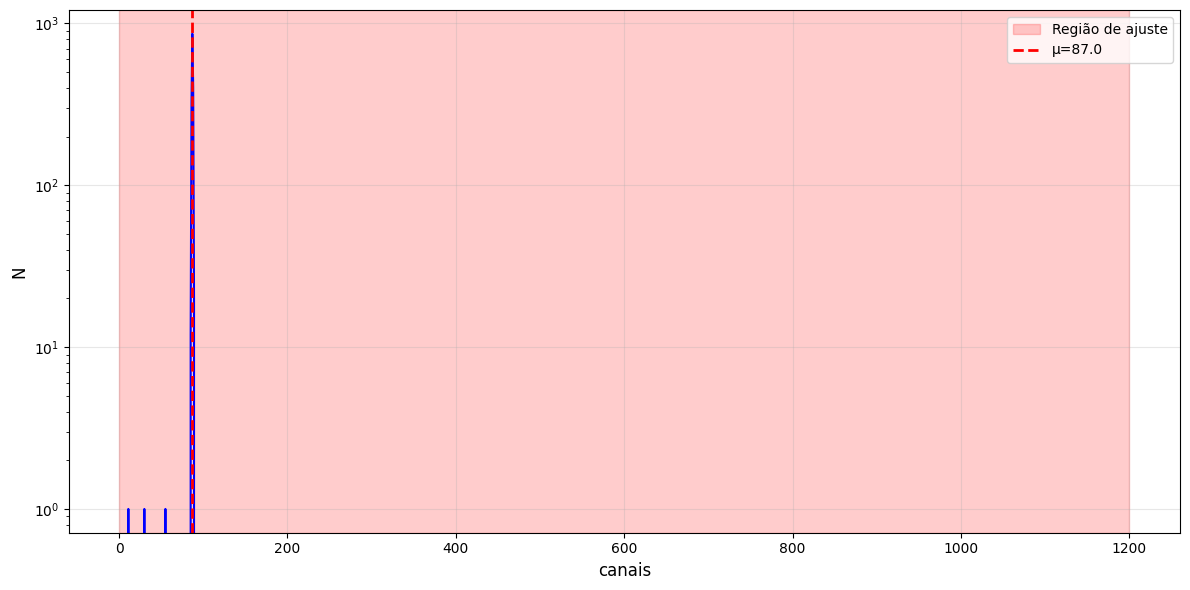

PULSER04: 
  μ = 86.9546 ± 0.0641; χ²_red = nan


In [99]:
channels_04, counts_04 = load_spectrum('PULSER04.ASC')

roi02_min, roi02_max = 0, 1200
roi02 = slice(roi02_min, roi02_max)
mu_04, sigma_04, chi2_04 = compute_stat(channels_04[roi02], counts_04[roi02], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_04, counts_04, 'b-', linewidth=1.5)
ax.axvspan(roi02_min, roi02_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_04, color='red', linestyle='--', linewidth=2, label=f'μ={mu_04:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER04: \n  μ = {mu_04:.4f} ± {sigma_04:.4f}; χ²_red = {chi2_04:.4f}")

Dial 0.6

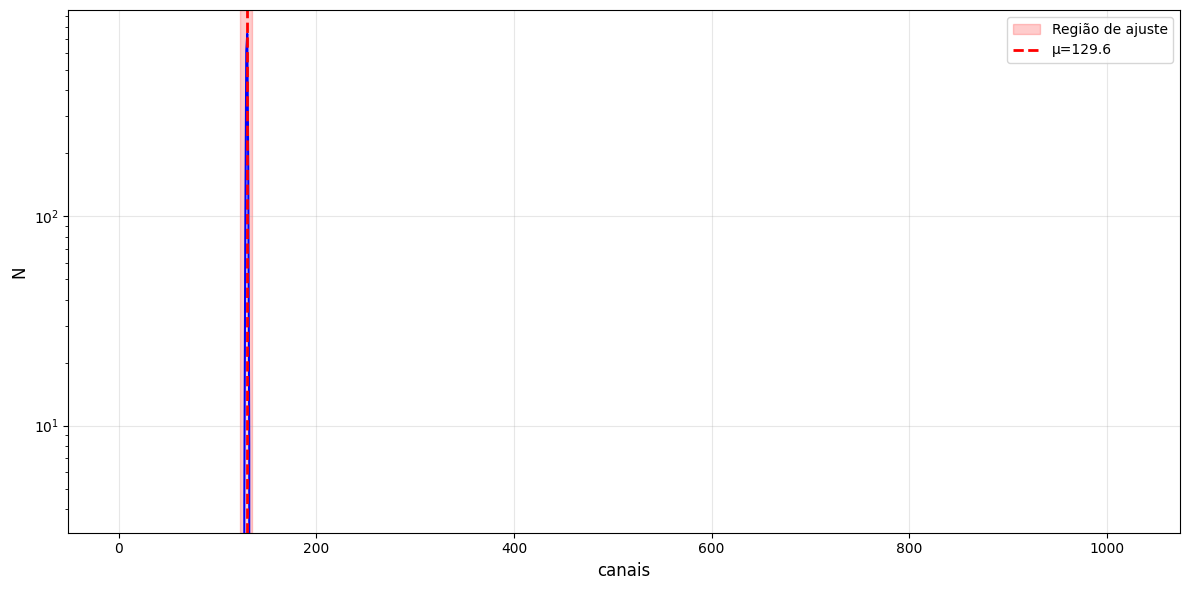

PULSER06: 
  μ = 129.6183 ± 0.0190; χ²_red = nan


In [100]:
channels_06, counts_06 = load_spectrum('PULSER06.ASC')

roi03_min, roi03_max = 123, 135
roi03 = slice(roi03_min, roi03_max)
mu_06, sigma_06, chi2_06 = compute_stat(channels_06[roi03], counts_06[roi03], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_06, counts_06, 'b-', linewidth=1.5)
ax.axvspan(roi03_min, roi03_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_06, color='red', linestyle='--', linewidth=2, label=f'μ={mu_06:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER06: \n  μ = {mu_06:.4f} ± {sigma_06:.4f}; χ²_red = {chi2_06:.4f}")

Dial 0.8

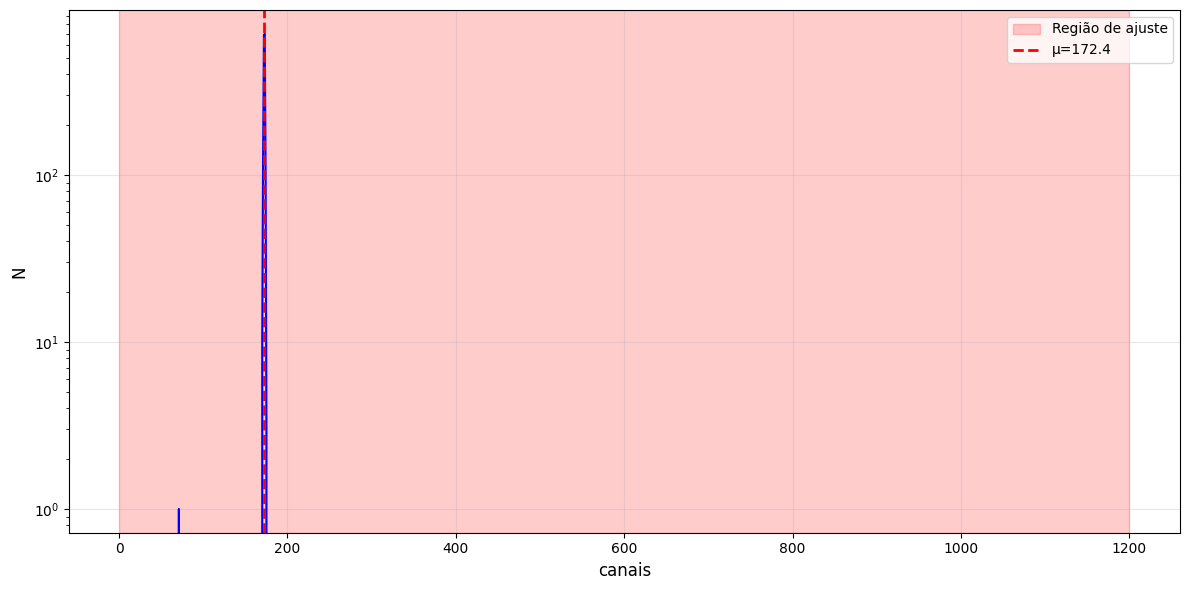

PULSER08: 
  μ = 172.4128 ± 0.0651; χ²_red = nan


In [101]:
channels_08, counts_08 = load_spectrum('PULSER08.ASC')

roi04_min, roi04_max = 0, 1200
roi04 = slice(roi04_min, roi04_max)
mu_08, sigma_08, chi2_08 = compute_stat(channels_08[roi04], counts_08[roi04], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_08, counts_08, 'b-', linewidth=1.5)
ax.axvspan(roi04_min, roi04_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_08, color='red', linestyle='--', linewidth=2, label=f'μ={mu_08:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER08: \n  μ = {mu_08:.4f} ± {sigma_08:.4f}; χ²_red = {chi2_08:.4f}")

Dial 1.0

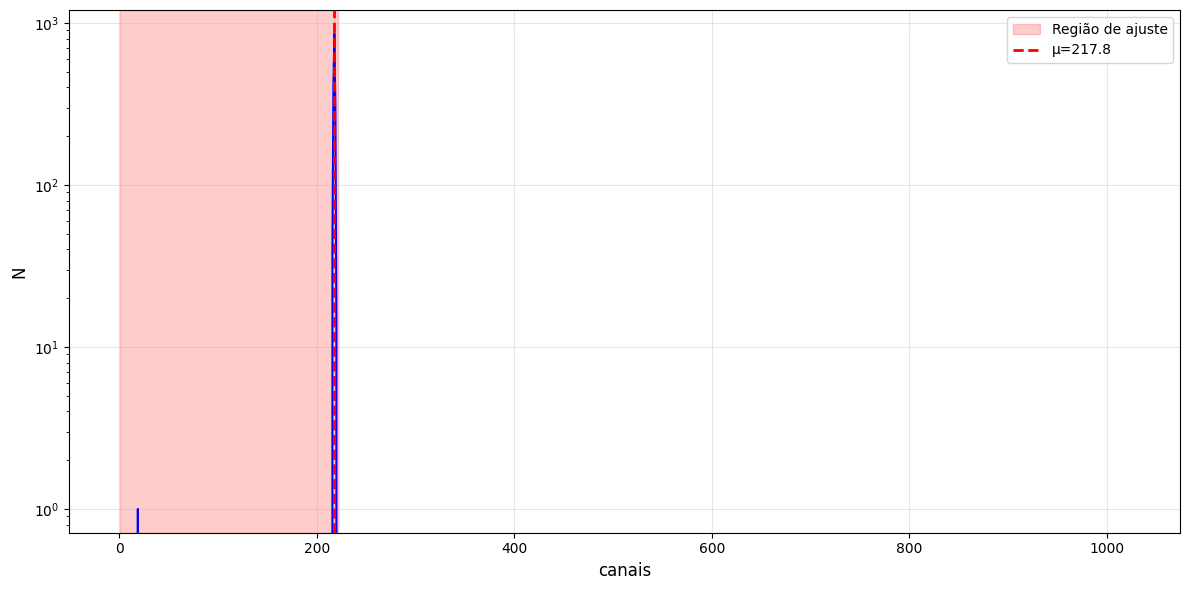

PULSER10: 
  μ = 217.7778 ± 0.1235; χ²_red = nan


In [102]:
channels_10, counts_10 = load_spectrum('PULSER10.ASC')

roi05_min, roi05_max = 1, 222
roi05 = slice(roi05_min, roi05_max)
mu_10, sigma_10, chi2_10 = compute_stat(channels_10[roi05], counts_10[roi05], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_10, counts_10, 'b-', linewidth=1.5)
ax.axvspan(roi05_min, roi05_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_10, color='red', linestyle='--', linewidth=2, label=f'μ={mu_10:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER10: \n  μ = {mu_10:.4f} ± {sigma_10:.4f}; χ²_red = {chi2_10:.4f}")

Dial 1.2

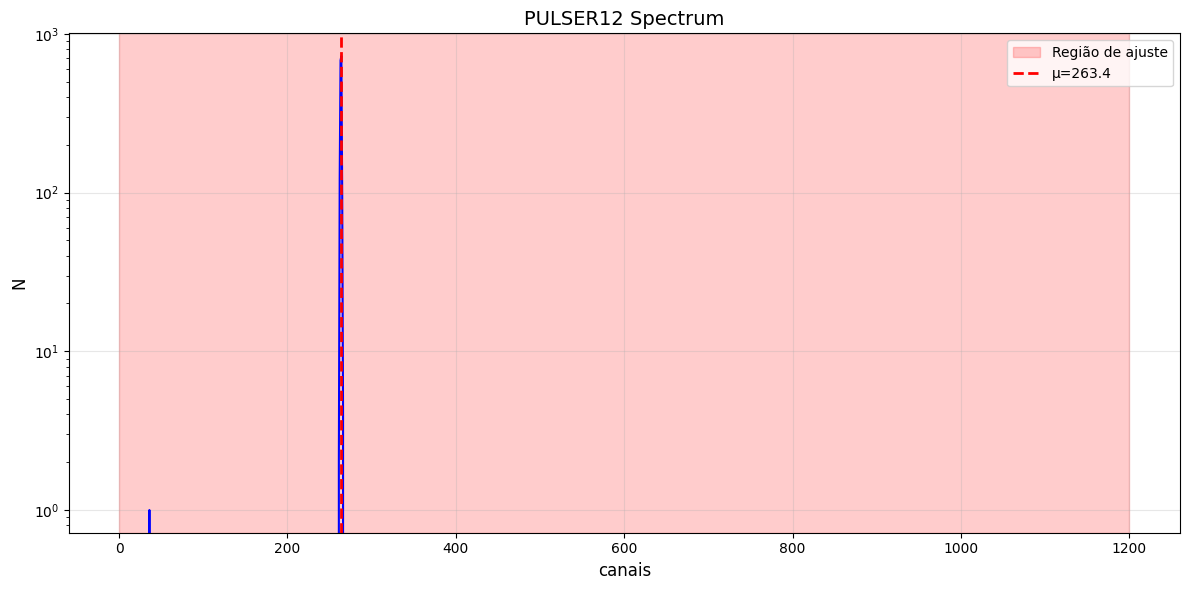

PULSER12: 
  μ = 263.3511 ± 0.1408; χ²_red = nan


In [103]:
channels_12, counts_12 = load_spectrum('PULSER12.ASC')

roi06_min, roi06_max = 0, 1200
roi06 = slice(roi06_min, roi06_max)
mu_12, sigma_12, chi2_12 = compute_stat(channels_12[roi06], counts_12[roi06], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_12, counts_12, 'b-', linewidth=1.5)
ax.axvspan(roi06_min, roi06_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_12, color='red', linestyle='--', linewidth=2, label=f'μ={mu_12:.1f}')
ax.set_yscale('log')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.set_title('PULSER12 Spectrum', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PULSER12: \n  μ = {mu_12:.4f} ± {sigma_12:.4f}; χ²_red = {chi2_12:.4f}")

# Calibração

Dials , $D$, para canais, $C$.
Reta:
$$
C = m_p D + b_p
$$

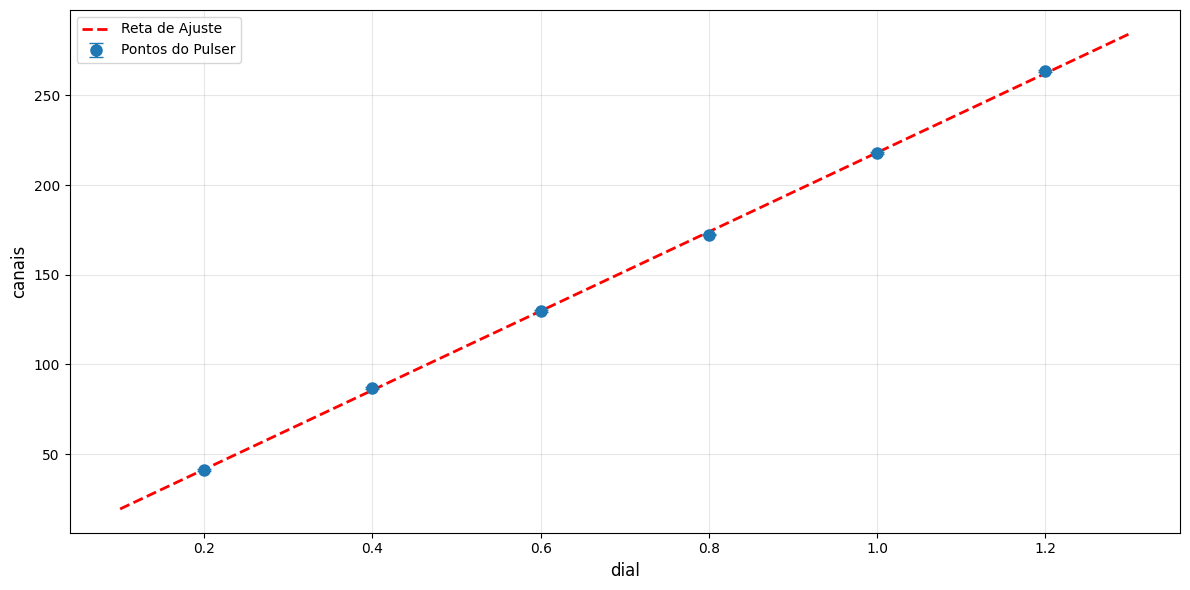

m_p = 220.695197 ± 1.396844 canais/dial
b_p = -2.58 ± 1.08 canais
χ²_red = 5.2592


In [ ]:
pulser_C = np.array([mu_02, mu_04, mu_06, mu_08, mu_10, mu_12])
pulser_C_sigma = np.sqrt(np.array([sigma_02, sigma_04, sigma_06, sigma_08, sigma_10, sigma_12])**2 + 0.5**2) #added systematical errors)
pulser_D = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

popt, pcov = optimize.curve_fit(linear, pulser_D, pulser_C, sigma=pulser_C_sigma)
perr = np.sqrt(np.diag(pcov))

pulser_C_fit = linear(pulser_D, *popt)

chi2 = compute_chi2(pulser_C, pulser_C_fit, dof=len(pulser_C) - 2)
chi2 = np.sum(((pulser_C - pulser_C_fit) ** 2) / pulser_C_sigma ** 2) / (len(pulser_C) - 2)  #different formula

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(pulser_D, pulser_C, yerr=pulser_C_sigma, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pontos do Pulser')
D_plot = np.linspace(pulser_D.min() - 0.1, pulser_D.max() + 0.1, 100)
ax.plot(D_plot, linear(D_plot, *popt), 'r--', linewidth=2, label=f'Reta de Ajuste')
ax.set_xlabel('dial', fontsize=12)
ax.set_ylabel('canais', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m_p = {popt[0]:.6f} ± {perr[0]:.6f} canais/dial")
print(f"b_p = {popt[1]:.2f} ± {perr[1]:.2f} canais")
print(f"χ²_red = {chi2:.4f}")

Agora traduzindo de dials para MeV, pegamos no pico de conversão do Cs-137, $C_{Cs}$,
$$D_{Cs} = \frac{C_{Cs} - b_p}{m_p}$$
Como o pulser é linear para a energia, ou seja, $D = 0 \implies E = 0\text{ MeV}$, temos a relação linear
$$ E_j = \kappa D_j $$
e podemos calcular $\kappa$, usando o pico conhecido, $\kappa = E_{Cs}/D_{Cs} $, onde $E_{Cs} = 624.215
\text{ keV}$ 

Assim, temos a nossa reta de calibração de canais para energia, $E$
$$
E = \frac{\kappa}{m_p}C - \frac{\kappa b_p}{m_p} = mC + b
$$



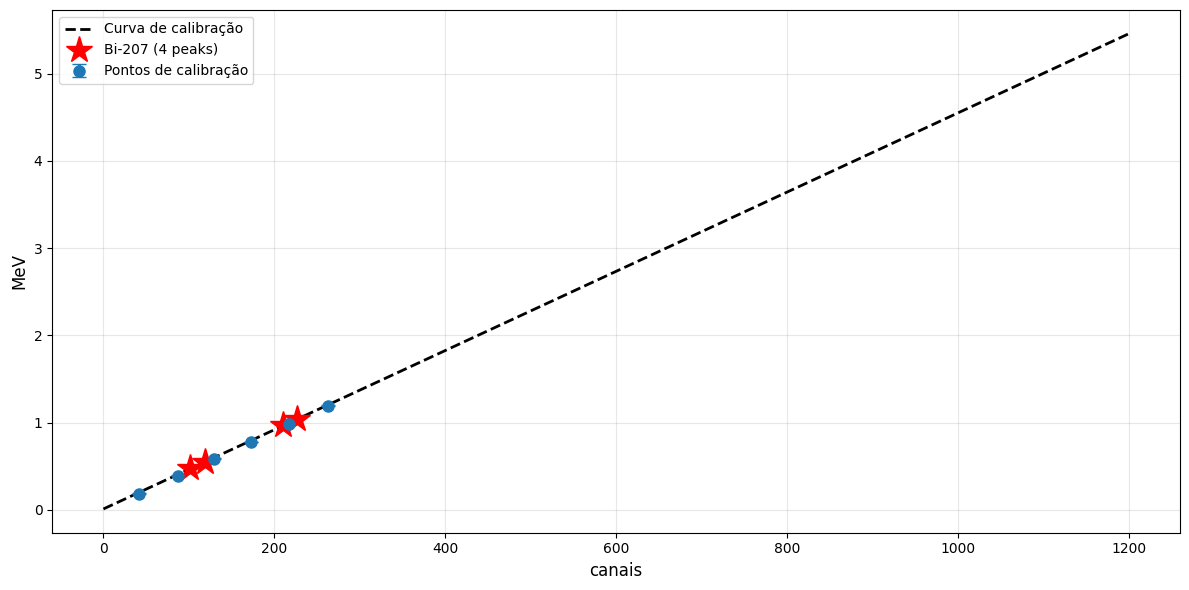

m = 0.0045370886 ± 0.0000433187 MeV/ch
b = 0.0117067067 ± 0.0048845914 MeV


In [ ]:
bi_conv_enes = np.array([0.4817, 0.5538, 0.9757, 1.0478])
bi_conv_mus = np.array([bi_conv_mu, bi_conv_1l_mu, bi_conv_2k_mu, bi_conv_2l_mu])
bi_conv_sigmas = np.array([bi_conv_sigma, bi_conv_1l_sigma, bi_conv_2k_sigma, bi_conv_2l_sigma])

# Convert all 4 Bi-207 peak channels to dials
bi_conv_dials = (bi_conv_mus - popt[1]) / popta[0]
bi_conv_dials_sigma = np.sqrt((bi_conv_sigmas / popt[0]) ** 2 + ((bi_conv_mus - popt[1]) * perr[0] / popt[0] ** 2) ** 2 + (perr[1] / popt[0]) ** 2)

# Fit all 4 Bi-207 points to get kappa
popt_bi, pcov_bi = optimize.curve_fit(linear, bi_conv_dials, bi_conv_enes, sigma=bi_conv_dials_sigma)
kappa = popt_bi[0]
kappa_sigma = np.sqrt(np.diag(pcov_bi))[0]

pulser_energies = kappa * pulser_D
#A incerteza dos dials é 0.01, menor divisão da escala
pulser_energies_sigma = np.sqrt((kappa_sigma * pulser_D) ** 2 + (kappa * 0.01) ** 2)

m = kappa/ popt[0]
m_sigma = np.sqrt((perr[0] * kappa/ popt[0]**2) ** 2 + (kappa_sigma/popt[0]) ** 2)
b = -popt[1] * kappa/popt[0]
b_sigma = np.sqrt((perr[1] * kappa / popt[0]) ** 2 + (popt[1] * kappa_sigma / popt[0]) ** 2 + (popt[1] * kappa * perr[0] / popt[0] ** 2) ** 2)

channels_plot = np.linspace(0, 1200, 1000)
energy_plot = m * channels_plot + b

pulser_energies_calib = m * pulser_C

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_plot, energy_plot, 'k--', linewidth=2, label='Curva de calibração')
ax.errorbar(pulser_C, pulser_energies_calib, yerr=pulser_C_sigma * m, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pontos de calibração')
ax.plot(bi_conv_mus, bi_conv_enes, 'r*', markersize=20, label='Bi-207 (4 peaks)')
ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('MeV', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m = {m:.10f} ± {m_sigma:.10f} MeV/ch")
print(f"b = {b:.10f} ± {b_sigma:.10f} MeV")

Calibração final:

$m = 0.005451 \pm 0.000074 \text{ MeV/ch}$

$b = 0.014417 \pm 0.006174 \text{ MeV}$

In [114]:
# Valores a 10 casas decimais
M_CALIB = 0.0045370886
B_CALIB = 0.0117067067
M_CALIB_SIGMA = 0.0000433187
B_CALIB_SIGMA = 0.0048845914

def calib(channels, sigma_channels=None):
    energy = linear(channels, M_CALIB, B_CALIB)
    if sigma_channels is not None:
        sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + (M_CALIB * sigma_channels)**2 + B_CALIB_SIGMA**2)
    else:
         sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + B_CALIB_SIGMA**2)
    return energy, sigma_energy

# Cs: Estimativa da espessura

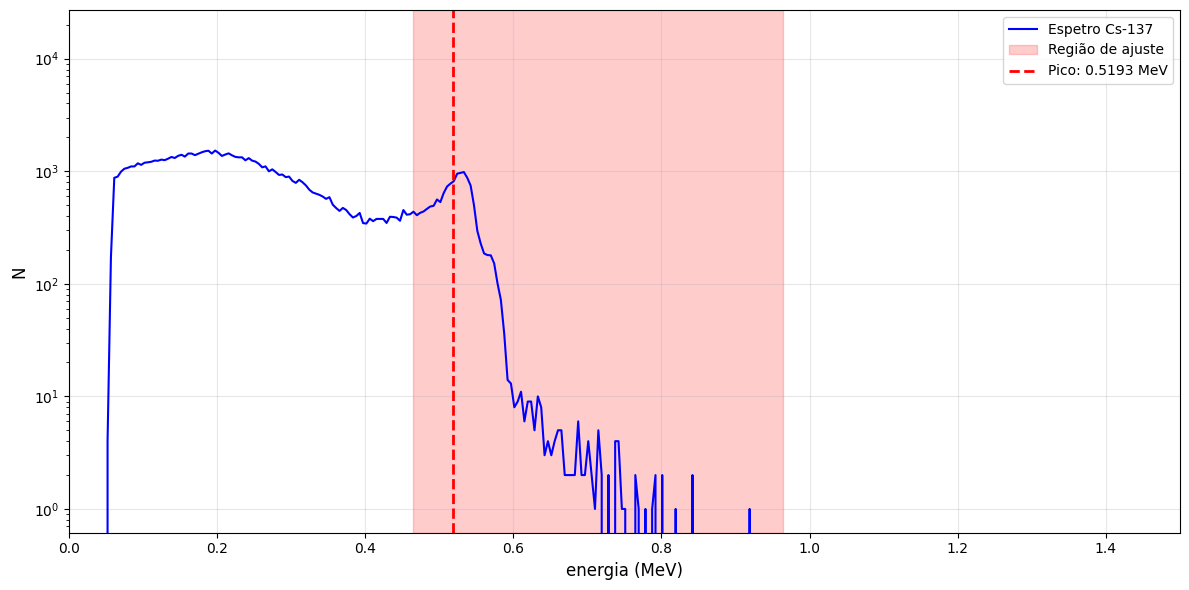

Cs-137: 
  μ = 0.519342 ± 0.006887 MeV; χ²_red = nan


In [131]:
cs_channels, cs_counts = load_spectrum('CPR1.ASC')
cs_ene, cs_ene_sigma = calib(cs_channels)

cs_conv_min, cs_conv_max = 100, 210
cs_conv_roi = slice(cs_conv_min, cs_conv_max)
cs_conv_mu_ch, cs_conv_sigma_ch, cs_conv_chi2 = compute_stat(cs_channels[cs_conv_roi], cs_counts[cs_conv_roi], model=None)
cs_conv_mu, cs_conv_sigma = calib(cs_conv_mu_ch, cs_conv_sigma_ch)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cs_ene, cs_counts, 'b-', linewidth=1.5, label='Espetro Cs-137')
ax.axvspan(cs_ene[cs_conv_min], cs_ene[cs_conv_max], alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(cs_conv_mu, color='r', linestyle='--', linewidth=2, label=f'Pico: {cs_conv_mu:.4f} MeV')
ax.set_yscale('log')
ax.set_xlabel('energia (MeV)', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.set_xlim(0, 1.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cs-137: \n  μ = {cs_conv_mu:.6f} ± {cs_conv_sigma:.6f} MeV; χ²_red = {cs_conv_chi2:.4f}")

Interpolação de $\partial_xE$

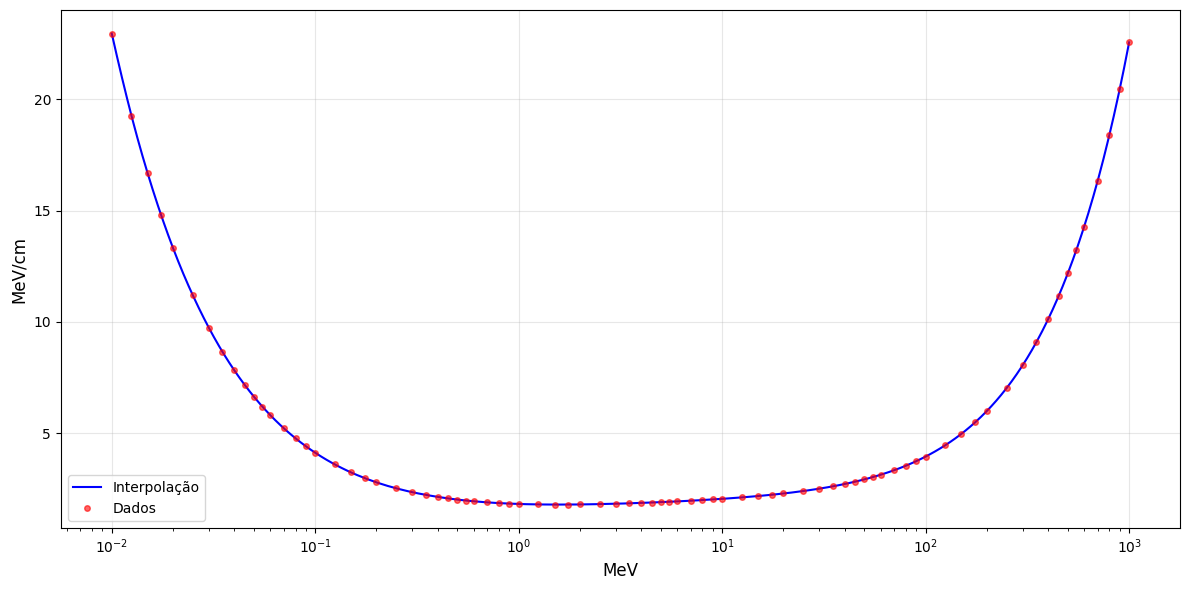

Δx = 0.053433 ± 0.003442 cm


In [136]:
cs_exp = 0.519342
cs_exp_sigma = 0.006887 
cs_theo = 0.624215

rho = 9.40000e-01 #g/cm³

energy = np.array([
    1.000E-02, 1.250E-02, 1.500E-02, 1.750E-02, 2.000E-02, 2.500E-02, 
    3.000E-02, 3.500E-02, 4.000E-02, 4.500E-02, 5.000E-02, 5.500E-02, 
    6.000E-02, 7.000E-02, 8.000E-02, 9.000E-02, 1.000E-01, 1.250E-01, 
    1.500E-01, 1.750E-01, 2.000E-01, 2.500E-01, 3.000E-01, 3.500E-01, 
    4.000E-01, 4.500E-01, 5.000E-01, 5.500E-01, 6.000E-01, 7.000E-01, 
    8.000E-01, 9.000E-01, 1.000E+00, 1.250E+00, 1.500E+00, 1.750E+00, 
    2.000E+00, 2.500E+00, 3.000E+00, 3.500E+00, 4.000E+00, 4.500E+00, 
    5.000E+00, 5.500E+00, 6.000E+00, 7.000E+00, 8.000E+00, 9.000E+00, 
    1.000E+01, 1.250E+01, 1.500E+01, 1.750E+01, 2.000E+01, 2.500E+01, 
    3.000E+01, 3.500E+01, 4.000E+01, 4.500E+01, 5.000E+01, 5.500E+01, 
    6.000E+01, 7.000E+01, 8.000E+01, 9.000E+01, 1.000E+02, 1.250E+02, 
    1.500E+02, 1.750E+02, 2.000E+02, 2.500E+02, 3.000E+02, 3.500E+02, 
    4.000E+02, 4.500E+02, 5.000E+02, 5.500E+02, 6.000E+02, 7.000E+02, 
    8.000E+02, 9.000E+02, 1.000E+03
])

stopping_power = np.array([
    2.442E+01, 2.049E+01, 1.775E+01, 1.573E+01, 1.417E+01, 1.192E+01, 
    1.036E+01, 9.209E+00, 8.328E+00, 7.630E+00, 7.062E+00, 6.591E+00, 
    6.194E+00, 5.560E+00, 5.077E+00, 4.695E+00, 4.387E+00, 3.825E+00, 
    3.446E+00, 3.174E+00, 2.970E+00, 2.687E+00, 2.501E+00, 2.373E+00, 
    2.277E+00, 2.204E+00, 2.147E+00, 2.103E+00, 2.068E+00, 2.015E+00, 
    1.980E+00, 1.956E+00, 1.939E+00, 1.917E+00, 1.910E+00, 1.911E+00, 
    1.916E+00, 1.932E+00, 1.950E+00, 1.970E+00, 1.989E+00, 2.008E+00, 
    2.026E+00, 2.044E+00, 2.061E+00, 2.094E+00, 2.126E+00, 2.156E+00, 
    2.184E+00, 2.253E+00, 2.317E+00, 2.379E+00, 2.439E+00, 2.556E+00, 
    2.670E+00, 2.782E+00, 2.893E+00, 3.004E+00, 3.114E+00, 3.223E+00, 
    3.333E+00, 3.551E+00, 3.769E+00, 3.987E+00, 4.205E+00, 4.749E+00, 
    5.294E+00, 5.839E+00, 6.385E+00, 7.479E+00, 8.574E+00, 9.671E+00, 
    1.077E+01, 1.187E+01, 1.297E+01, 1.407E+01, 1.517E+01, 1.737E+01, 
    1.958E+01, 2.179E+01, 2.400E+01
])

S = stopping_power * rho

stopping_power_interp = interp1d(energy, S, kind='cubic', fill_value='extrapolate')

E_plot = np.logspace(np.log10(energy.min()), np.log10(energy.max()), 200)
S_plot = stopping_power_interp(E_plot)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(E_plot, S_plot, 'b-', linewidth=1.5, label='Interpolação')
ax.plot(energy, S, 'ro', markersize=4, alpha=0.6, label='Dados')
ax.set_xscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('MeV/cm', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def delta_x(E1, E2):
    integrand = lambda E: 1 / stopping_power_interp(E)
    result, error = quad(integrand, E1, E2)
    return result

def delta_x_with_error(E1, E2, sigma_E1, sigma_E2):
    dx = delta_x(E1, E2)
    
    # Error propagation: ∂Δx/∂E1 = -1/S(E1), ∂Δx/∂E2 = 1/S(E2)
    dS1 = stopping_power_interp(E1)
    dS2 = stopping_power_interp(E2)
    
    sigma_dx = np.sqrt((sigma_E1 / dS1)**2 + (sigma_E2 / dS2)**2)
    
    return dx, sigma_dx

dx, sigma_dx = delta_x_with_error(cs_exp, cs_theo, cs_exp_sigma, 0)

print(f"Δx = {dx:.6f} ± {sigma_dx:.6f} cm") 


In [139]:
csda_range = np.array([
    2.308E-04, 3.430E-04, 4.745E-04, 6.244E-04, 7.921E-04, 1.179E-03, 
    1.630E-03, 2.143E-03, 2.715E-03, 3.343E-03, 4.025E-03, 4.758E-03, 
    5.541E-03, 7.249E-03, 9.134E-03, 1.118E-02, 1.339E-02, 1.952E-02, 
    2.642E-02, 3.399E-02, 4.215E-02, 5.991E-02, 7.924E-02, 9.979E-02, 
    1.213E-01, 1.437E-01, 1.667E-01, 1.902E-01, 2.142E-01, 2.632E-01, 
    3.133E-01, 3.641E-01, 4.155E-01, 5.452E-01, 6.759E-01, 8.068E-01, 
    9.375E-01, 1.197E+00, 1.455E+00, 1.710E+00, 1.963E+00, 2.213E+00, 
    2.461E+00, 2.707E+00, 2.950E+00, 3.431E+00, 3.905E+00, 4.372E+00, 
    4.833E+00, 5.960E+00, 7.054E+00, 8.119E+00, 9.157E+00, 1.116E+01, 
    1.307E+01, 1.491E+01, 1.667E+01, 1.837E+01, 2.000E+01, 2.158E+01, 
    2.310E+01, 2.601E+01, 2.874E+01, 3.132E+01, 3.377E+01, 3.936E+01, 
    4.434E+01, 4.883E+01, 5.293E+01, 6.015E+01, 6.639E+01, 7.188E+01, 
    7.678E+01, 8.120E+01, 8.523E+01, 8.893E+01, 9.235E+01, 9.851E+01, 
    1.039E+02, 1.088E+02, 1.131E+02
])

csda = csda_range * rho

csda_interp = interp1d(energy, csda, kind='cubic', fill_value='extrapolate')

deltax_csda = csda_interp(cs_theo) - csda_interp(cs_exp)
sigma_deltax_csda = np.sqrt((csda_interp(cs_exp + cs_exp_sigma) - csda_interp(cs_exp - cs_exp_sigma))**2 + (csda_interp(cs_theo + 0.01) - csda_interp(cs_theo - 0.01))**2) / 2

print(f"Δx (CSDA) = {deltax_csda:.6f} ± {sigma_deltax_csda:.6f} cm")

Δx (CSDA) = 0.047210 ± 0.005491 cm
